# Next Steps
- Evaluate other period setups (e.g. agging data to weekly or biweekly and calculating outliers there)
- Evaluate admin-specific appraoch (calc outliers for each admin / time period combo individually)
- Create dict of KP IDs for final dataframe so as to easily link outliers to event descriptions (or some other method but playing dictionaries is fun)
- Evaluate other methods including Arima based band construction and rolling window-based clustering methods / also check out z-scores (or filtering data for last two years and clustering) - covid makes it tough as there is undoubtedly a structural shift. See attempts in master branch of git repository.

In [1]:
#Basic
import pandas as pd
import numpy as np
from pandas.core.reshape.merge import merge_asof
import datetime
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt

#Packates
import adtk
from adtk.detector import PersistAD
from adtk.visualization import plot
from sklearn.ensemble import IsolationForest

In [2]:
#### Functions ###
# Convert ACLED Dates to pd
def convert_dt(value):
    valstr = str(value)
    date_clean = datetime(year=int(valstr[0:4]), month=int(valstr[4:6]), day=int(valstr[6:8]))
    return date_clean

# Rolling Window 
def rolling_window(df, window = 30, IQR_x = 1.5):
    persist_ad = PersistAD(window=window, c=IQR_x, side='positive')
    df['rw_anomalies'] = persist_ad.fit_detect(df)
    return df



In [3]:
# Import Data

## Conflict Main
conflict = pd.read_csv('SriLanka_ACLED_Extract_march1.csv')

In [4]:
### Data Transformation
## Format Time Series
# Convert int to dtime - inefficient but who cares given small obs size
# Look into python packages available that have better support for time series manipulation
# Pandas (as you can see by this cell) is absolutely terrible

conflict_ts = conflict.copy()
conflict_ts['Date_Clean'] = conflict_ts['TimeFK_Event_Date'].apply(lambda x: convert_dt(x))
conflict_ts[['Date_Clean','TimeFK_Event_Date']]

# Filter by year
conflict_ts = conflict_ts[conflict_ts['Date_Clean'].dt.year >= 2014]

# Aggregate
# Standard
dailydata = conflict_ts.groupby(['Date_Clean']).agg({'Date_Clean':'count'}).rename(columns={'Date_Clean':'Event_Count'})

#Optional dict with kp ids in case we want to link to actor analysis later on
# dailydata = conflict_ts.groupby(['Date_Clean']).agg({'Date_Clean':'count'}).rename(columns={'Date_Clean':'Event_Count'})


# Optional - fill empty dates with zeros
dailydata = dailydata.resample('D').sum().fillna(0)


0.0    2387
1.0     188
Name: rw_anomalies, dtype: int64
[<AxesSubplot:> <AxesSubplot:>]
Event_Count     20.209302
rw_anomalies     1.093023
dtype: float64
0.0    75
1.0    50
2.0    24
3.0    10
4.0     8
5.0     3
7.0     1
6.0     1
Name: rw_anomalies, dtype: int64


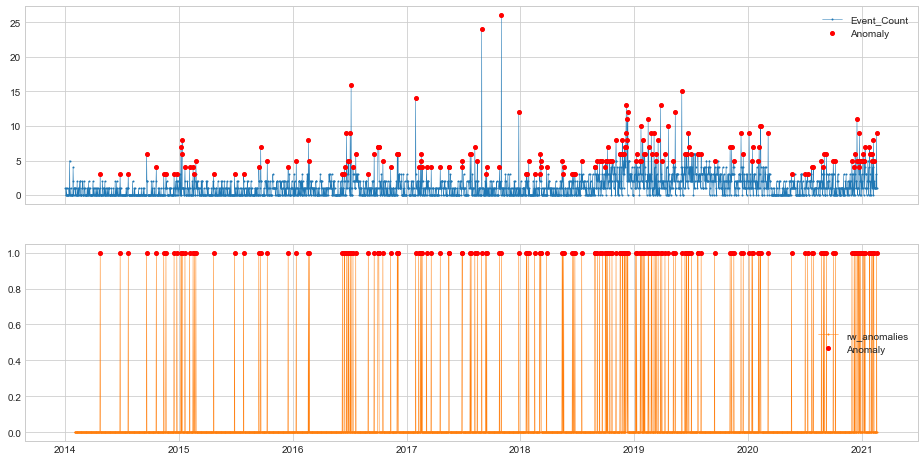

In [13]:
### Old Skool Methods
## Rolling Window
# Params for rolling window
# window = 30 (default) - number of periods to account for
# IQR_x = 1.5 (default - threshold band, increase absolute value for a higher minimum threshold 

# Calculate with default (30 days)
dailydata_iqr = rolling_window(dailydata)

# Calc with 90 days
# dailydata_iqr = rolling_window(dailydata, window = 90)

# # Cal with higher Threshold and 60 days
# dailydata_iqr = rolling_window(dailydata, window = 60, IQR_x=3)

# Examine number of outliers
print(dailydata_iqr['rw_anomalies'].value_counts()) # 188 anaomalies detected


# Plot results
print(plot(dailydata, anomaly=dailydata_iqr['rw_anomalies'], anomaly_color="red", anomaly_tag="marker"))

# Examine biweekly average
biweekly = dailydata.resample('SMS').sum()
# Average number of anomalies per two week period - should also plot the distribution
print(biweekly.mean())
print(biweekly['rw_anomalies'].value_counts())

## 1.093 anomalies per two weeks for a 30 day average - seems reasonable
## average drops to 0.4 if you upgrade threshold to 3
## Examine second graph for observable seasonality

In [6]:
# Check distribution of means via graph here


[<AxesSubplot:>]

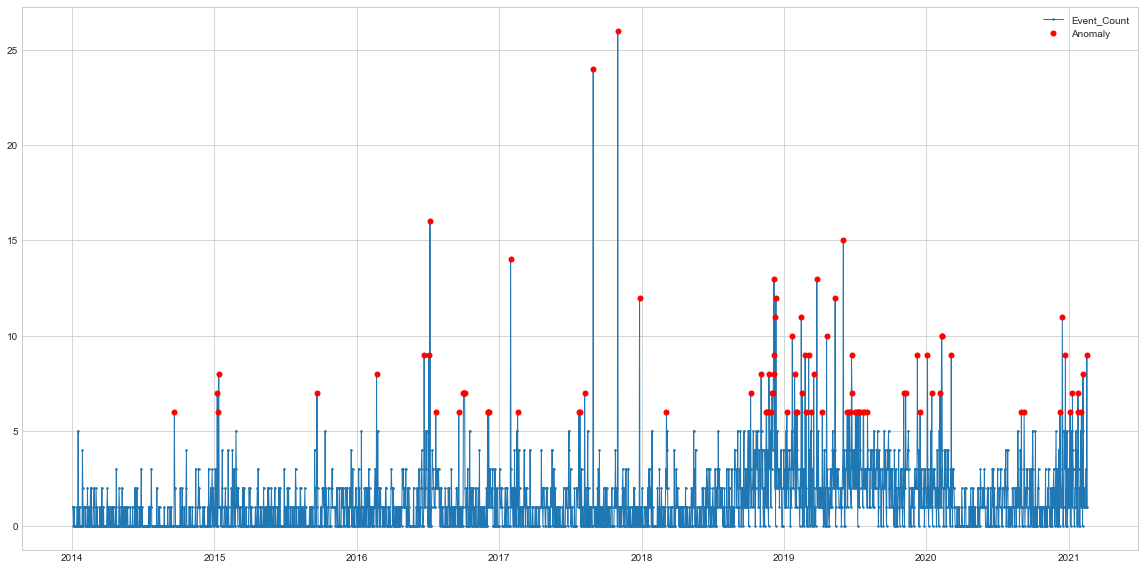

In [7]:
### Tree-Based ###
## Isolation Forest - Global solutions just don't work as well i feel due to the change nature of conflict
## Could try calculating these into rolling windows but then both clustering and efficiency becomes problamatic
IForest = IsolationForest(contamination=0.05)
dailydata_if = IForest.fit_predict(np.array(dailydata.Event_Count).reshape(-1,1))
dailydata_if = pd.Series([x == -1 for x in dailydata_if], index=dailydata.index)
plot(dailydata.Event_Count, anomaly=dailydata_if, ts_linewidth=1, ts_markersize=3, anomaly_color='red', figsize=(20,10), anomaly_tag="marker", anomaly_markersize=5)